In [3]:
import numpy as np
import matplotlib.pyplot as plt

import umap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

KeyboardInterrupt: 

In [32]:
# Read in the training and test set
test_in = np.genfromtxt('data/test_in - Copy.csv', delimiter=',')
test_out = np.genfromtxt('data/test_out - Copy.csv', delimiter=',', dtype=int)
train_in = np.genfromtxt('data/train_in - Copy.csv', delimiter=',')
train_out = np.genfromtxt('data/train_out - Copy.csv', delimiter=',', dtype=int)

# Task 1

In [33]:
# Create buffer for the means
means = np.empty((10, 256))

for i in range(10):
    # For each digit mask out location in training output 
    digit_mask = (train_out == i)

    # Calculate the mean of the digit's input images 
    means[i] = np.mean(train_in[digit_mask], axis=0)

Most similar digits: (7, 9), distance: 5.426474119055888
Most different digits: (0, 1), distance: 14.44960796590658


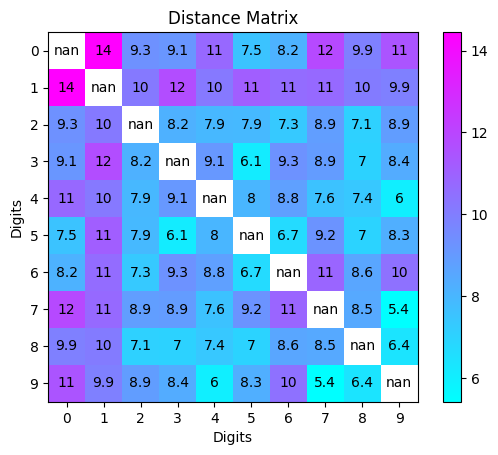

In [34]:
min_dist = np.inf
max_dist = 0

distances = dict()

for i in range(10):
    for j in range(i+1, 10):
        dist = np.sqrt(np.sum((means[i] - means[j])**2))

        distances[(i,j)] = dist

        # print(f"{i}, {j}: {dist}")
        if dist < min_dist:
            min_dist = dist
            min_pair = i, j
        if dist > max_dist:
            max_dist = dist
            max_pair = i, j
    
print(f"Most similar digits: {min_pair}, distance: {min_dist}")
print(f"Most different digits: {max_pair}, distance: {max_dist}")

# print(f'\nAll distances:\n ')
# for key in distances.keys():
#     print(f'{key} distance: {distances[key]:.2f}')

# Store the distances in a grid for visualization
cm = np.full((10,10), np.nan)
for key in distances.keys():
    flipped = key[::-1]

    # Assign value to grid point and its mirror image along diagonal
    cm[key] = distances[key]
    cm[flipped] = distances[key]

# Display distances between pairs
ConfusionMatrixDisplay(cm).plot(cmap='cool', text_kw={'c':'k'})
plt.title("Distance Matrix")
plt.xlabel('Digits')
plt.ylabel('Digits')
plt.savefig('imgs/dist_matrix.pdf')
plt.show()

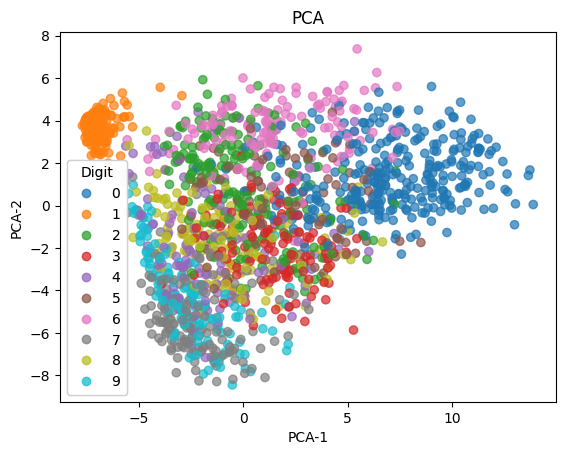

In [35]:
# Reduce the dimensionality of training set using PCA
train_in_pca = PCA(n_components=2).fit_transform(train_in).T

# Plot the embedded points
scatter = plt.scatter(train_in_pca[0], train_in_pca[1], c=train_out, cmap='tab10', alpha=0.7)

# Create one label per color
legend = plt.legend(
    *scatter.legend_elements(),
    title="Digit"
)
plt.gca().add_artist(legend)

plt.title("PCA")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.savefig('imgs/PCA.pdf')
plt.show()

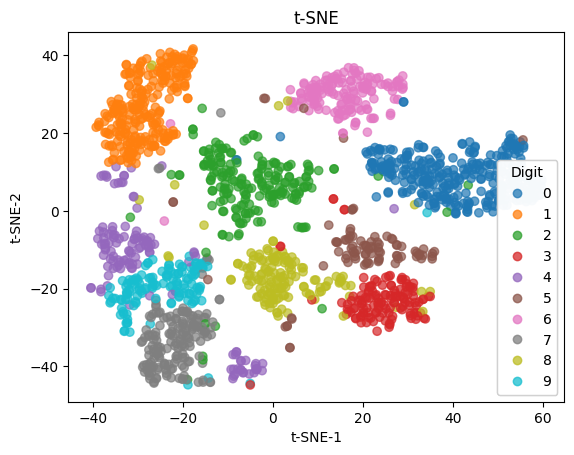

In [36]:
# Reduce the dimensionality of the training set using tSNE
train_in_tsne = TSNE(n_components=2).fit_transform(train_in).T

# Scatter the embedded points
scatter = plt.scatter(train_in_tsne[0], train_in_tsne[1], c=train_out, cmap='tab10', alpha=0.7)

# Create a label per digit
legend = plt.legend(
    *scatter.legend_elements(),
    title="Digit"
)
plt.gca().add_artist(legend)

plt.title("t-SNE")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.savefig('imgs/tSNE.pdf')
plt.show()

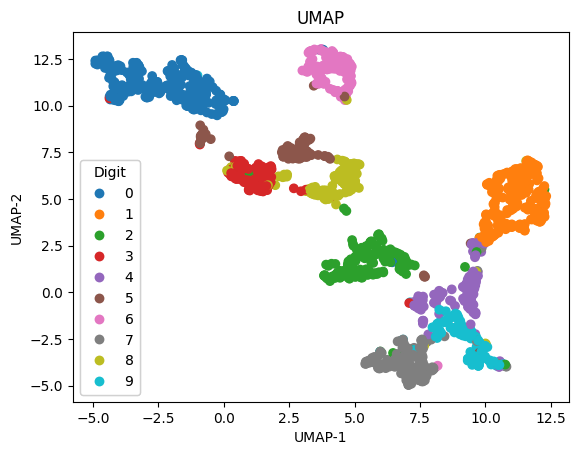

In [37]:
train_in_umap  = umap.UMAP(n_neighbors=5, min_dist=0.1).fit_transform(train_in).T
scatter = plt.scatter(train_in_umap[0], train_in_umap[1], c=train_out, cmap='tab10')

legend = plt.legend(
    *scatter.legend_elements(),
    title="Digit"
)

plt.gca().add_artist(legend)

plt.title("UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.savefig('imgs/umap.pdf')
plt.show()

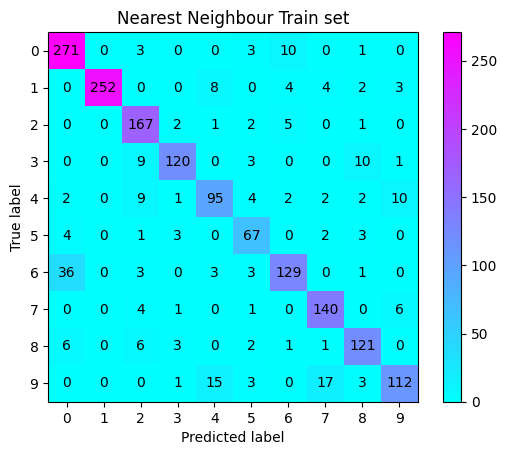

 Training set accuracy: 0.864


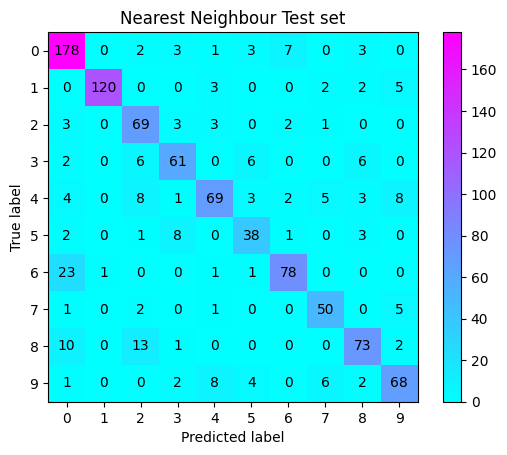

Test set accuracy: 0.804


In [38]:
### Training set

min_distances = np.empty(len(train_in))
labels = np.empty(len(train_in))

for i in range(10):
    distances = np.sum((train_in - means[i])**2, axis=1)
    if i == 0:
        min_distances = distances
        labels = np.zeros(len(train_in))
    else:
        mask = distances < min_distances
        labels[mask] = i
        min_distances[mask] = distances[mask]

# Plotting
ConfusionMatrixDisplay(confusion_matrix(labels, train_out)).plot(cmap='cool', text_kw={'c':'k'})
plt.title('Nearest Neighbour Train set')
plt.savefig('imgs/NN_train.pdf')
plt.show()

# Accuracy
print(f' Training set accuracy: {np.sum(labels == train_out) / len(train_out):.3f}')


### Test set

min_distances = np.empty(len(test_in))
labels = np.empty(len(test_in))

for i in range(10):
    distances = np.sum((test_in - means[i])**2, axis=1)
    if i == 0:
        min_distances = distances
        labels = np.zeros(len(test_in))
    else:
        mask = distances < min_distances
        labels[mask] = i
        min_distances[mask] = distances[mask]

# Plotting
ConfusionMatrixDisplay(confusion_matrix(labels, test_out)).plot(cmap='cool', text_kw={'c':'k'})
plt.title('Nearest Neighbour Test set')
plt.savefig('imgs/NN_test.pdf')
plt.show()

# Accuracy
print(f'Test set accuracy: {np.sum(labels == test_out) / len(test_out):.3f}')

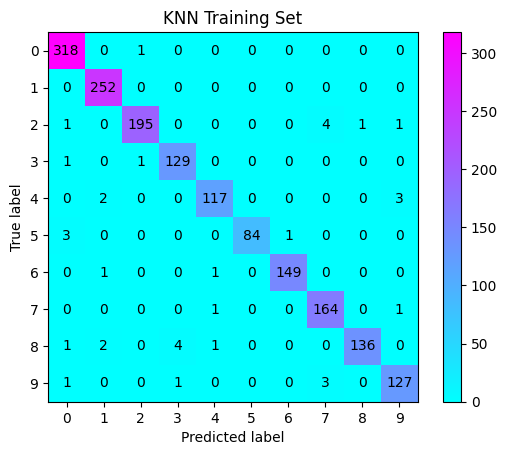

Training set accuracy: 0.979


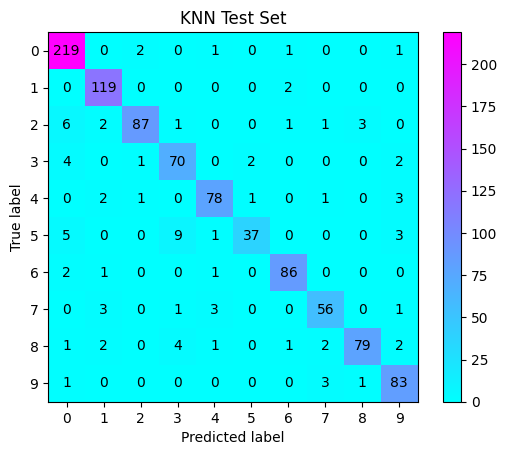

Test set accuracy: 0.914


In [39]:
### KNN
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(train_in, train_out)
labels_pred_train = neigh.predict(train_in)
labels_pred_test = neigh.predict(test_in)

# Plotting
ConfusionMatrixDisplay(confusion_matrix(train_out, labels_pred_train)).plot(cmap='cool', text_kw={'c':'k'})
plt.title("KNN Training Set")
plt.savefig('imgs/KNN_train.pdf')
plt.show()

# Accuracy
print(f'Training set accuracy: {np.sum(labels_pred_train == train_out) / len(train_out):.3f}')

# Plotting
ConfusionMatrixDisplay(confusion_matrix(test_out, labels_pred_test)).plot(cmap='cool', text_kw={'c':'k'})
plt.savefig('imgs/KNN_test.pdf')
plt.title("KNN Test Set")
plt.show()

# Accuracy
print(f'Test set accuracy: {np.sum(labels_pred_test == test_out) / len(test_out):.3f}')

### Task 2

In [ ]:
class MultiClassPerceptron():
    def __init__(self, num_input, num_classes):
        self.number_weight = num_input + 1
        self.num_classes = num_classes
        self.weight = np.random.normal(0, 1, (self.number_weight, self.num_classes)) / (self.number_weight * self.num_classes)
    
    def train(self, input, output, n_steps=1000, learning_rate=1e-6):
        # Add a row of ones to the input for the bias
        input_plus_bias = np.hstack([input, np.ones((input.shape[0], 1))])

        self.loss = np.zeros(n_steps)
        self.learning_rate = np.zeros(n_steps)

        for i in range(n_steps):
            # Apply the weights to the input
            model = input_plus_bias @ self.weight

            # Calculate the MSE
            residual = model - output
            self.loss[i] = np.mean((model - output)**2)

            # Find the gradient of the linear model
            gradient =  2 * input_plus_bias.T @ residual
                
            # Apply gradient to the weights to update them
            self.weight -= learning_rate * gradient
    
    def predict(self, input):
        # Add a row of ones to the input for the bias
        input_plus_bias = np.hstack([input, np.ones((input.shape[0], 1))])

        # Apply the weights to the input plus the bias
        return input_plus_bias @ self.weight

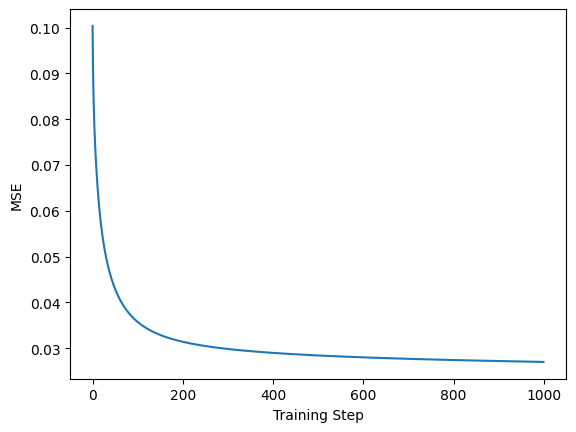

In [58]:
# Initiate the classifier
classifier = MultiClassPerceptron(256, 10)

# Convert the digits into positional output for the training
vector_label = np.eye(10)[train_out]

# Train the classifier onn the training set
classifier.train(train_in, vector_label, 1000, learning_rate=1e-6)

# Plot the MSE
plt.plot(classifier.loss)
plt.xlabel('Training Step')
plt.ylabel('MSE')
plt.savefig('imgs/MSE.pdf')
plt.show()

In [59]:
digits = np.arange(10)

# Finding the predicition by taking the digit with the highest value
prediction = digits[np.argmax(classifier.predict(train_in), axis=1)]
correct = np.sum(prediction==train_out)

# Print the training result
print(f'Training set accuracy: {correct/len(prediction):.3f}')

# Finding the predicition by taking the digit with the highest value
prediction = digits[np.argmax(classifier.predict(test_in), axis=1)]
correct = np.sum(prediction==test_out)

# Print the test result
print(f'Test set accuracy: {correct/len(prediction):.3f}')

Training set accuracy: 0.926
Test set accuracy: 0.865


Task 3

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

100%|██████████| 1/1 [00:01<00:00,  1.54s/it]

[0 0] 0 0.33377396686422567
[0 1] 1 0.981962159574031
[1 0] 1 0.333432219982449
[1 1] 0 0.33355098834425945


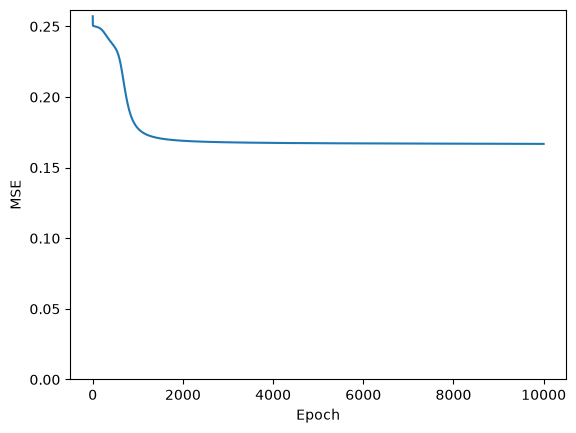

In [5]:
class NeuralNetworkXOR():
    def __init__(self):
        a = 0.5
        self.weights_0 = np.random.normal(0, a, (3, 2))
        self.weights_1 = np.random.normal(0, a, (3, 1))
        self.x_all = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        self.y_all = np.array([0, 1, 1, 0])

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict(self, input):
        """
        x: (input) neuron including bias
        f = bias + weights * x
        h = sigmoid(f)
        """
        x = np.append(input, 1)

        self.f0 = x @ self.weights_0
        # print(x, self.weights_0)
        self.h0 = self.sigmoid(self.f0)
        self.x1 = np.append(self.h0, 1)

        self.f1 = self.x1 @ self.weights_1
        self.y = self.sigmoid(self.f1)

        return self.y
    
    def mse(self):
        """Calculate MSE and number of misclassifications"""
        err = np.array([])
        self.num_mistakes = 0
        for X, Y in zip(self.x_all, self.y_all):
            err = np.append(err, (Y - (self.predict(X)))**2)
            if abs(Y - self.predict(X)[0]) > 0.5:
                self.num_mistakes += 1

        mse = np.mean(err)
        return [mse, self.num_mistakes]


    def gradients(self):

        self.gradient_b0 = 0
        self.gradient_w0 = 0
        self.gradient_b1 = 0
        self.gradient_w1 = 0

        for X, Y in zip(self.x_all, self.y_all):
            self.predict(X)

            self.gradient_f1 = (self.y - Y) * (1 - self.y) * self.y
            
            self.gradient_b1 += self.gradient_f1
            self.gradient_w1 += self.gradient_f1 * self.h0 

            self.gradient_f0 = np.diag(self.h0*(1 - self.h0)) @ self.weights_1[:2] * self.gradient_f1
            self.gradient_b0 += self.gradient_f0
            self.gradient_w0 += self.gradient_f0 @ X.reshape((1,2))

        self.gradients0 = np.append(self.gradient_w0, self.gradient_b0.T, axis=0)
        # print(self.gradients0)
        self.gradients1 = np.append(self.gradient_w1, self.gradient_b1.T, axis=0)
        # print(self.gradients1)

    def train(self, num_epoch, learning_rate):

        self.mse_array = np.empty(num_epoch)

        for i in range(num_epoch):
            self.gradients()
            delta_weights_0 = learning_rate * self.gradients0
            self.weights_0 -= delta_weights_0

            delta_weights_1 = learning_rate * np.array([self.gradients1]).T
            # print(delta_weights_1, self.weights_1)
            self.weights_1 -= delta_weights_1

            self.mse_array[i] = self.mse()[0]



num_it = 1
mse_array = np.empty(num_it)
mistakes_array = np.empty(num_it)

#train and test 'num_it' amount of models
for i in tqdm(range(num_it)):
    test = NeuralNetworkXOR()

    test.train(num_epoch=10000, learning_rate=0.75)

    for X, Y in zip(test.x_all, test.y_all):
        prediction = test.predict(X)
        print(X, Y, prediction[0])

    mse_megarray = np.array([test.mse_array]) if i == 0 else np.append(mse_megarray, np.array([test.mse_array]), axis=0)
    mse_array[i] = test.mse_array[-1]
    mistakes_array[i] = test.num_mistakes


plt.plot(test.mse_array)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.ylim(0)
plt.show()

In [6]:
# np.save('mse_megarray.npy', mse_megarray)
# np.save('mistakes_array.npy', mistakes_array)

mse_megarray = np.load('mse_megarray.npy', )
mistakes_array = np.load('mistakes_array.npy')

[0.28305352 0.26951258 0.26071654 ... 0.12525323 0.1252532  0.12525318]
[0.25526951 0.2524979  0.25115528 ... 0.00041904 0.00041898 0.00041891]
[0.26709167 0.25873168 0.25426739 ... 0.16831547 0.16831475 0.16831404]


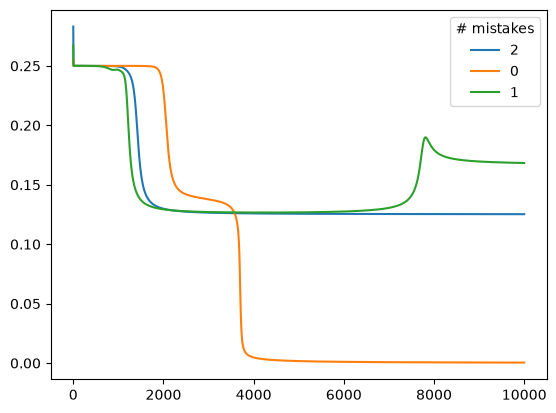

In [7]:
p=11
for i, arr in enumerate(mse_megarray[p:p+3]):
    print(arr)
    plt.plot(arr, label=int(mistakes_array[i+p]))

plt.legend(title='# mistakes')
plt.show()